# Лабораторная работа 2. Многослойный персептрон (МЛП)

**Цель работы:** Реализовать архитектуру многослойного персептрона и алгоритм обратного распространения ошибки для обучения сети.

- **2.1** МЛП-регрессор — предсказание числовой оценки **G3** (0–20)
- **2.2** МЛП-классификатор — предсказание **pass** (сдал / не сдал)

---

## Подготовка датасета (алгоритм из ЛР1)

**Описание метода:** Препроцессинг (предварительная обработка данных) — обязательный этап перед обучением любой модели машинного обучения. Включает чистку данных (удаление дубликатов, обработку пропусков и выбросов), кодирование категориальных признаков, анализ корреляций с помощью тепловой матрицы для удаления избыточных признаков, а также отбор наиболее информативных признаков с использованием алгоритма Gain Ratio — метрики из алгоритма построения деревьев решений C4.5, которая оценивает информативность признака относительно целевой переменной с поправкой на количество его уникальных значений.

## 1. Используемые библиотеки

In [1]:
from google.colab import files

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay
)

print('Все библиотеки успешно импортированы!')

Все библиотеки успешно импортированы!


## 2. Загрузка и описание датасета

**О датасете:** Данные собраны в двух португальских средних школах. Содержат демографические, социальные и школьные характеристики 395 учащихся, а также их оценки по математике за три периода (G1, G2, G3). Датасет используется для предсказания итоговой оценки (G3).

**Целевая переменная:** `pass` — бинарный признак (1 = сдал: G3 ≥ 10, 0 = не сдал: G3 < 10).

**Всего признаков:** 33 (числовые и категориальные).

In [2]:
# Загружаем файл (выберите student-mat.csv)
uploaded = files.upload()
df = pd.read_csv('dataset.csv', sep=';')

print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
print('\n--- Первые 5 строк ---')
display(df.head())

Saving dataset.csv to dataset.csv
Размер датасета: 395 строк, 33 столбцов

--- Первые 5 строк ---


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
print('--- Типы данных и наличие значений ---')
print(df.info())
print('\n--- Базовая статистика числовых признаков ---')
display(df.describe())

--- Типы данных и наличие значений ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery    

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


## 3. Предварительная обработка датасета (Препроцессинг)

### 3.1 Проверка пропущенных значений и дубликатов

In [4]:
print('=== Пропущенные значения по каждому признаку ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'Пропущенных значений не обнаружено.')

print(f'\n=== Дубликаты ===')
print(f'Количество дублирующихся строк: {df.duplicated().sum()}')
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print('Дубликаты удалены.')

print(f'\nИтоговый размер датасета после проверки: {df.shape}')

=== Пропущенные значения по каждому признаку ===
Пропущенных значений не обнаружено.

=== Дубликаты ===
Количество дублирующихся строк: 0

Итоговый размер датасета после проверки: (395, 33)


**Вывод:** В датасете отсутствуют пропущенные значения — данные были собраны с помощью анкетирования и школьных отчётов, что обеспечило полноту записей. Дубликаты также отсутствуют. Восстановление данных не требуется.

### 3.2 Создание целевой переменной (бинаризация G3)

Распределение целевой переменной (pass):
pass
1    265
0    130
Name: count, dtype: int64

Доля сдавших: 67.1%


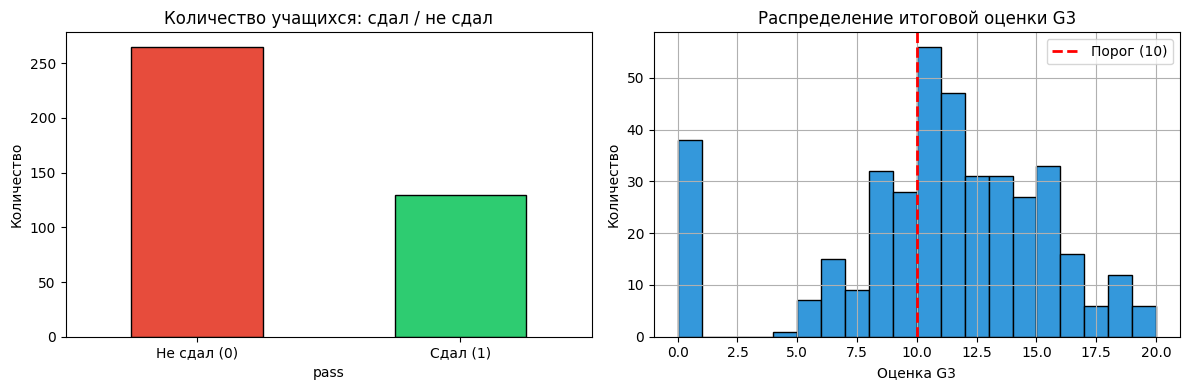

In [5]:
# Создаём бинарную целевую переменную: сдал (1) / не сдал (0)
# Порог 10 — стандартная проходная оценка в португальской школьной системе (из 20 баллов)
df['pass'] = (df['G3'] >= 10).astype(int)

print('Распределение целевой переменной (pass):')
print(df['pass'].value_counts())
print(f'\nДоля сдавших: {df["pass"].mean():.1%}')

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['pass'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Количество учащихся: сдал / не сдал')
axes[0].set_xticklabels(['Не сдал (0)', 'Сдал (1)'], rotation=0)
axes[0].set_ylabel('Количество')

df['G3'].hist(bins=20, ax=axes[1], color='#3498db', edgecolor='black')
axes[1].axvline(x=10, color='red', linestyle='--', linewidth=2, label='Порог (10)')
axes[1].set_title('Распределение итоговой оценки G3')
axes[1].set_xlabel('Оценка G3')
axes[1].set_ylabel('Количество')
axes[1].legend()

plt.tight_layout()
plt.show()

**Обоснование:** Итоговая оценка G3 имеет числовой формат (0–20), что делает её пригодной и для регрессии, и для классификации. Для задачи препроцессинга мы преобразуем её в бинарный признак «сдал / не сдал» по стандартному португальскому порогу 10 баллов из 20. Это упрощает задачу и делает модель практически интерпретируемой.

### 3.3 Обнаружение и обработка выбросов

In [6]:
# Анализ числовых признаков на выбросы методом IQR
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['G1', 'G2', 'G3', 'pass']]

print('=== Анализ выбросов (метод IQR) ===')
outlier_info = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    if n_outliers > 0:
        outlier_info.append({'Признак': col, 'Выбросов': n_outliers,
                              'Нижняя граница': round(lower, 2),
                              'Верхняя граница': round(upper, 2),
                              'Макс. значение': df[col].max()})

if outlier_info:
    display(pd.DataFrame(outlier_info))
else:
    print('Критических выбросов не обнаружено.')

=== Анализ выбросов (метод IQR) ===


,Признак,Выбросов,Нижняя граница,Верхняя граница,Макс. значение
0,age,1,13.0,21.0,22
1,Fedu,2,0.5,4.5,4
2,traveltime,8,-0.5,3.5,4
3,studytime,27,-0.5,3.5,4
4,failures,83,0.0,0.0,3
5,famrel,26,2.5,6.5,5
6,freetime,19,1.5,5.5,5
7,Dalc,18,-0.5,3.5,5
8,absences,15,-12.0,20.0,75


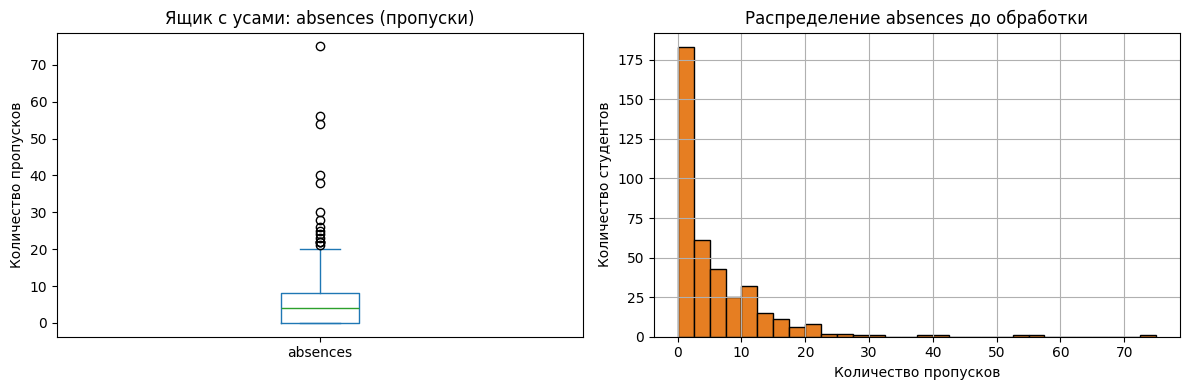

Верхняя граница для absences: 20.0
Студентов с absences > 20.0: 15

После обработки: max absences = 20


In [7]:
# Визуализируем признак absences — у него самый широкий диапазон (0–93)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['absences'].plot(kind='box', ax=axes[0])
axes[0].set_title('Ящик с усами: absences (пропуски)')
axes[0].set_ylabel('Количество пропусков')

df['absences'].hist(bins=30, ax=axes[1], color='#e67e22', edgecolor='black')
axes[1].set_title('Распределение absences до обработки')
axes[1].set_xlabel('Количество пропусков')
axes[1].set_ylabel('Количество студентов')

plt.tight_layout()
plt.show()

# Ограничиваем выбросы верхней границей IQR (Winsorizing)
Q1 = df['absences'].quantile(0.25)
Q3 = df['absences'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR

print(f'Верхняя граница для absences: {upper_fence}')
print(f'Студентов с absences > {upper_fence}: {(df["absences"] > upper_fence).sum()}')

# Применяем Winsorizing — заменяем экстремальные значения на верхнюю границу
df['absences'] = df['absences'].clip(upper=upper_fence)
print(f'\nПосле обработки: max absences = {df["absences"].max()}')

**Обоснование:** Признак `absences` (пропуски занятий) имеет максимальное значение 93, тогда как 75-й процентиль равен 8. Это сильные выбросы, которые могут исказить работу модели. Вместо удаления строк применяем **Winsorizing** — заменяем экстремальные значения верхней границей IQR (Q3 + 1.5·IQR). Это позволяет сохранить все 395 записей, лишь сглаживая крайние значения.

### 3.4 Кодирование категориальных признаков

In [8]:
# Бинарные признаки — кодируем вручную (Label Encoding)
binary_map = {
    'school':     {'GP': 0, 'MS': 1},
    'sex':        {'F': 0, 'M': 1},
    'address':    {'R': 0, 'U': 1},
    'famsize':    {'LE3': 0, 'GT3': 1},
    'Pstatus':    {'A': 0, 'T': 1},
    'schoolsup':  {'no': 0, 'yes': 1},
    'famsup':     {'no': 0, 'yes': 1},
    'paid':       {'no': 0, 'yes': 1},
    'activities': {'no': 0, 'yes': 1},
    'nursery':    {'no': 0, 'yes': 1},
    'higher':     {'no': 0, 'yes': 1},
    'internet':   {'no': 0, 'yes': 1},
    'romantic':   {'no': 0, 'yes': 1},
}

for col, mapping in binary_map.items():
    df[col] = df[col].map(mapping)

print('Бинарные признаки закодированы (Label Encoding):')
print(list(binary_map.keys()))

# Номинальные (многозначные) признаки — One-Hot Encoding
nominal_cols = ['Mjob', 'Fjob', 'reason', 'guardian']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=False, dtype=int)

print(f'\nПосле One-Hot Encoding номинальных признаков:')
print(f'Новые признаки: {[c for c in df.columns if any(n in c for n in nominal_cols)]}')
print(f'\nИтоговое число признаков: {df.shape[1]}')

Бинарные признаки закодированы (Label Encoding):
['school', 'sex', 'address', 'famsize', 'Pstatus', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

После One-Hot Encoding номинальных признаков:
Новые признаки: ['Mjob_at_home', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_at_home', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_course', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_father', 'guardian_mother', 'guardian_other']

Итоговое число признаков: 47


**Обоснование:**
- **Label Encoding** применён к бинарным признакам (только 2 значения), так как между ними нет порядкового отношения, которое могло бы ввести модель в заблуждение.
- **One-Hot Encoding** применён к номинальным признакам с 3+ значениями (`Mjob`, `Fjob`, `reason`, `guardian`). Это позволяет избежать ложной ординальности — модель не будет считать, что «teacher > health > services».

## 4. Тепловая карта корреляций и удаление зависимых признаков

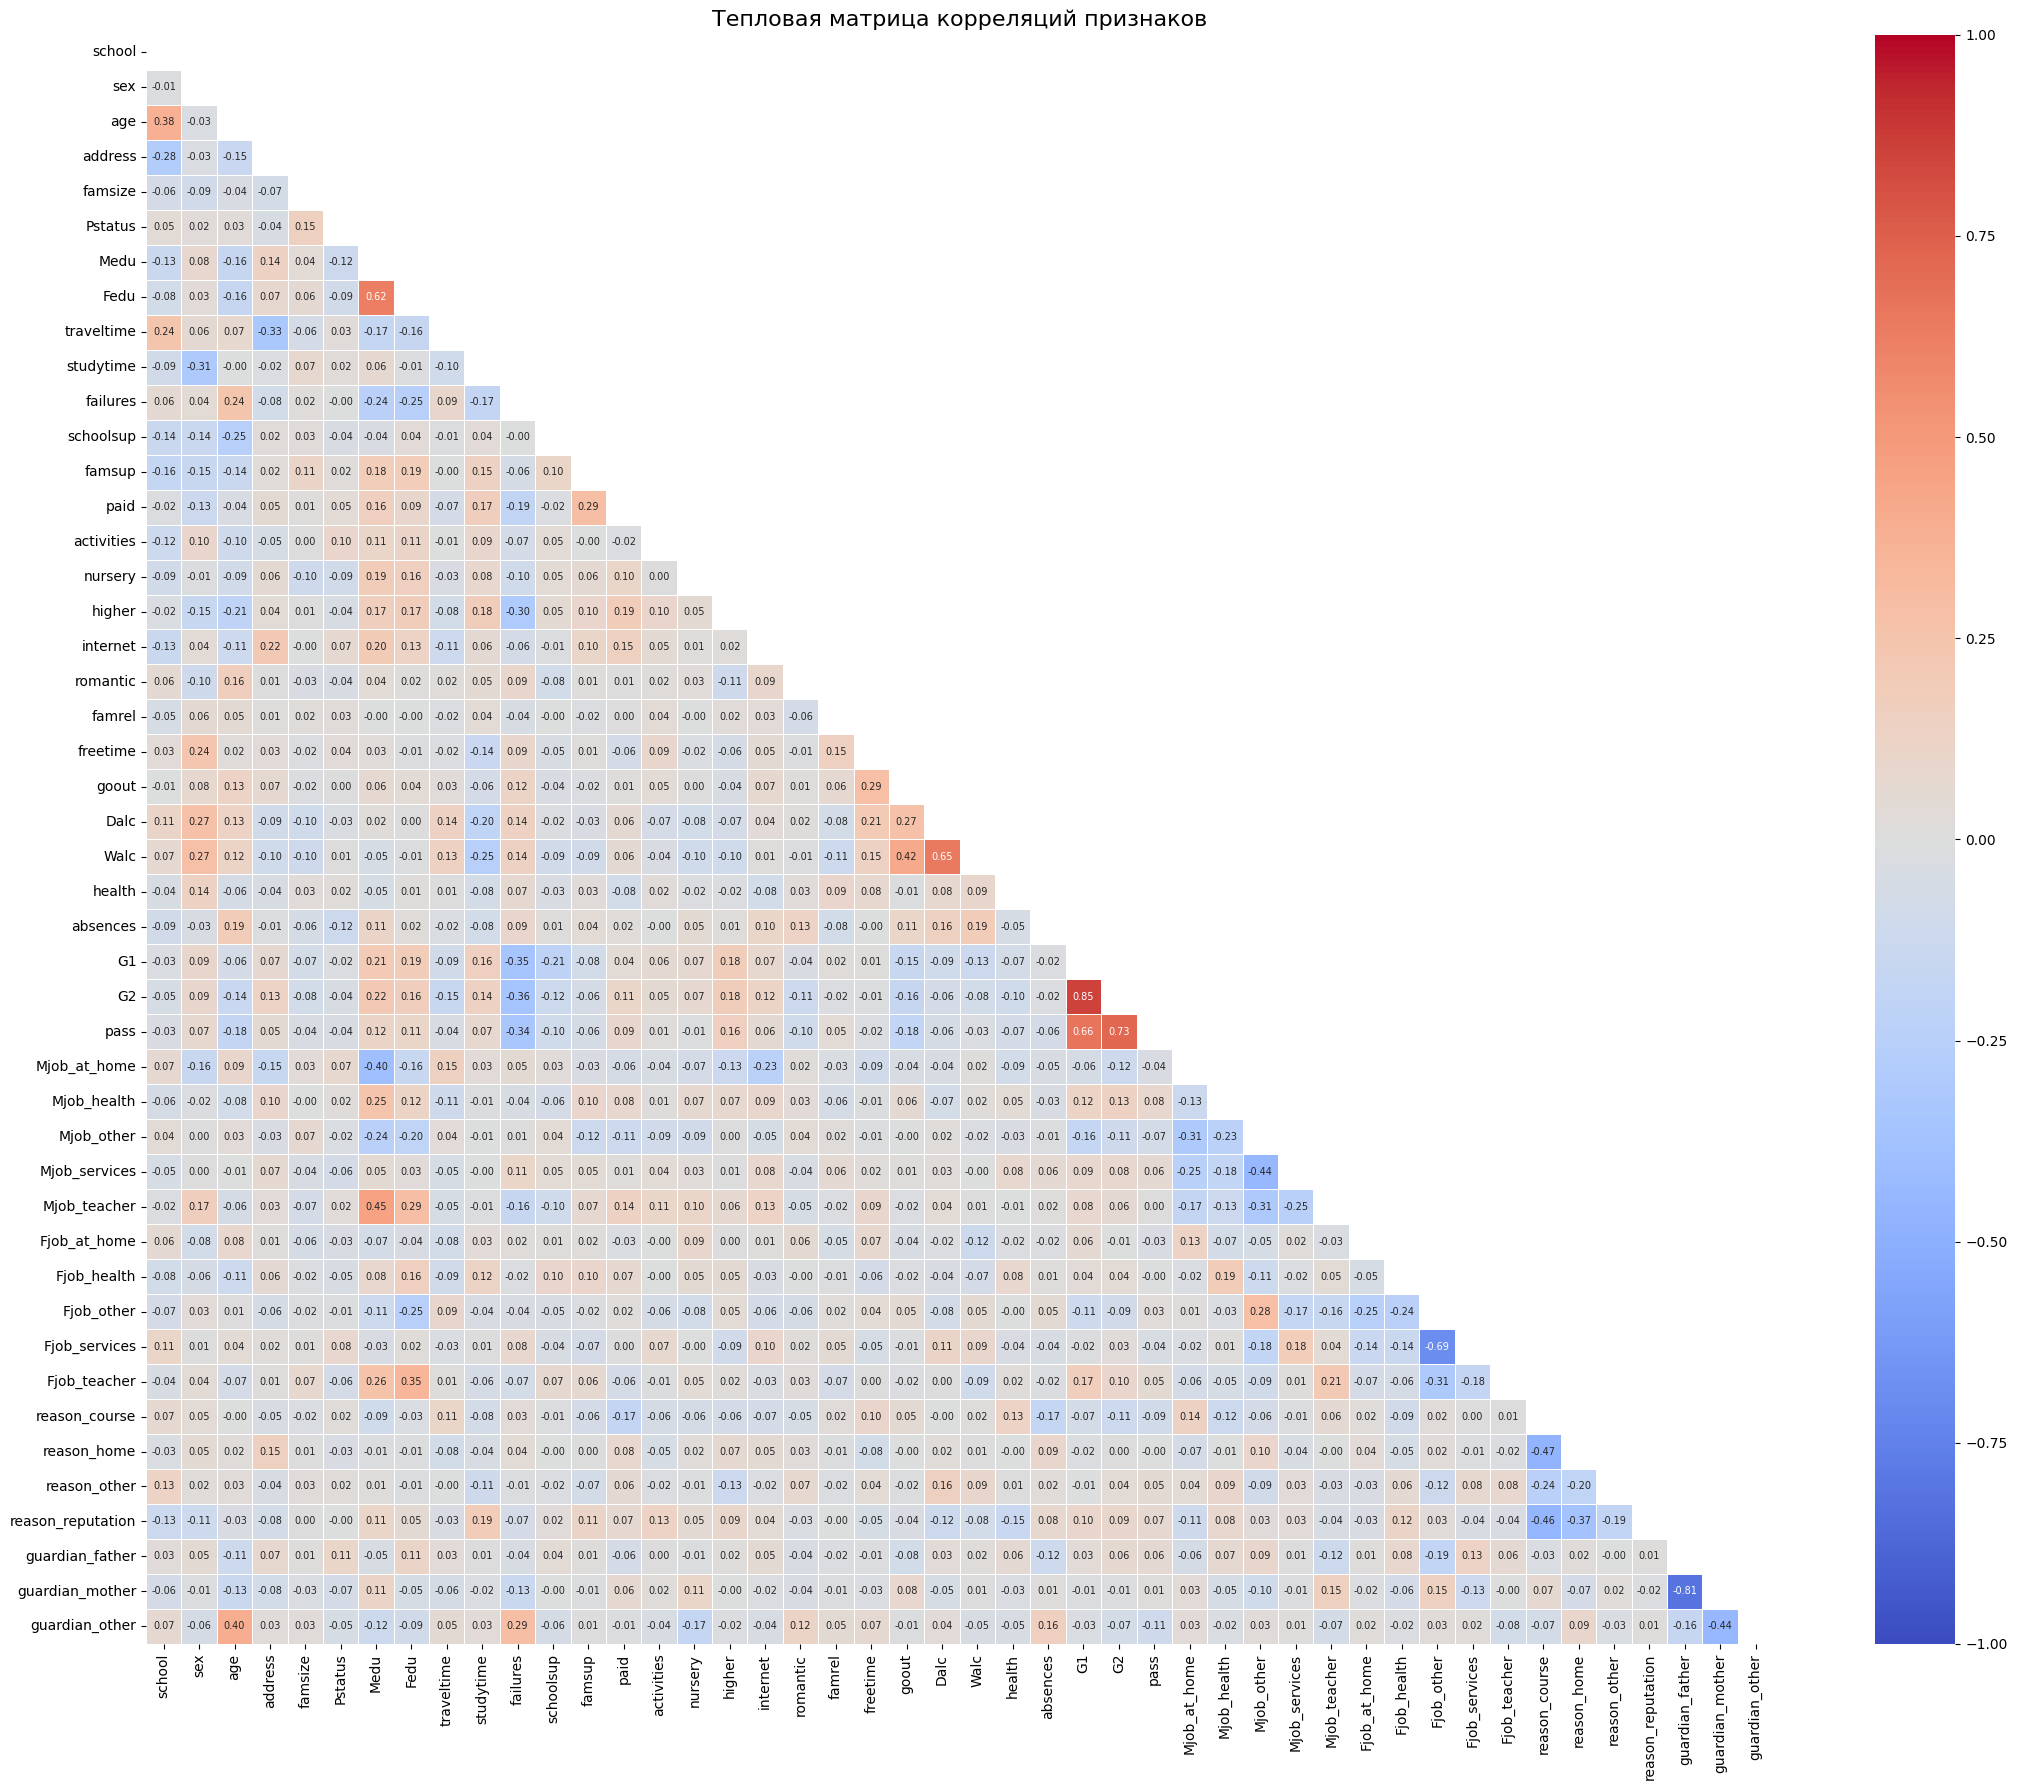

In [9]:
# Берём только числовые признаки (после кодирования — все числовые)
# Исключаем G1, G2, G3 — они прямые компоненты целевой переменной
df_for_corr = df.drop(columns=['G3'])  # G3 уже в 'pass'

corr_matrix = df_for_corr.corr()

plt.figure(figsize=(22, 18))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # показываем только нижний треугольник

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 7},
    vmin=-1, vmax=1
)
plt.title('Тепловая матрица корреляций признаков', fontsize=16)
plt.tight_layout()
plt.show()

Мультиколлинеарные пары (|r|>0.8):


,Признак 1,Признак 2,Корреляция
0,guardian_father,guardian_mother,0.813


Признаков после шага 1: 42

=== Корреляция признаков с pass ===
failures             0.337731
goout                0.183399
age                  0.179645
higher               0.157708
Medu                 0.115396
Fedu                 0.108057
guardian_other       0.107977
schoolsup            0.099860
romantic             0.097737
paid                 0.092665
reason_course        0.092534
Mjob_health          0.080484
studytime            0.074613
Mjob_other           0.074163
sex                  0.070618
reason_reputation    0.067771
health               0.065668
absences             0.064083
internet             0.061791
Mjob_services        0.060114
guardian_father      0.059347
famsup               0.059219
Dalc                 0.057343
reason_other         0.053316
Fjob_teacher         0.052557
address              0.052282
famrel               0.046683
traveltime           0.044446
Pstatus              0.044050
famsize              0.041842
Fjob_services        0.041572
Mjob_a

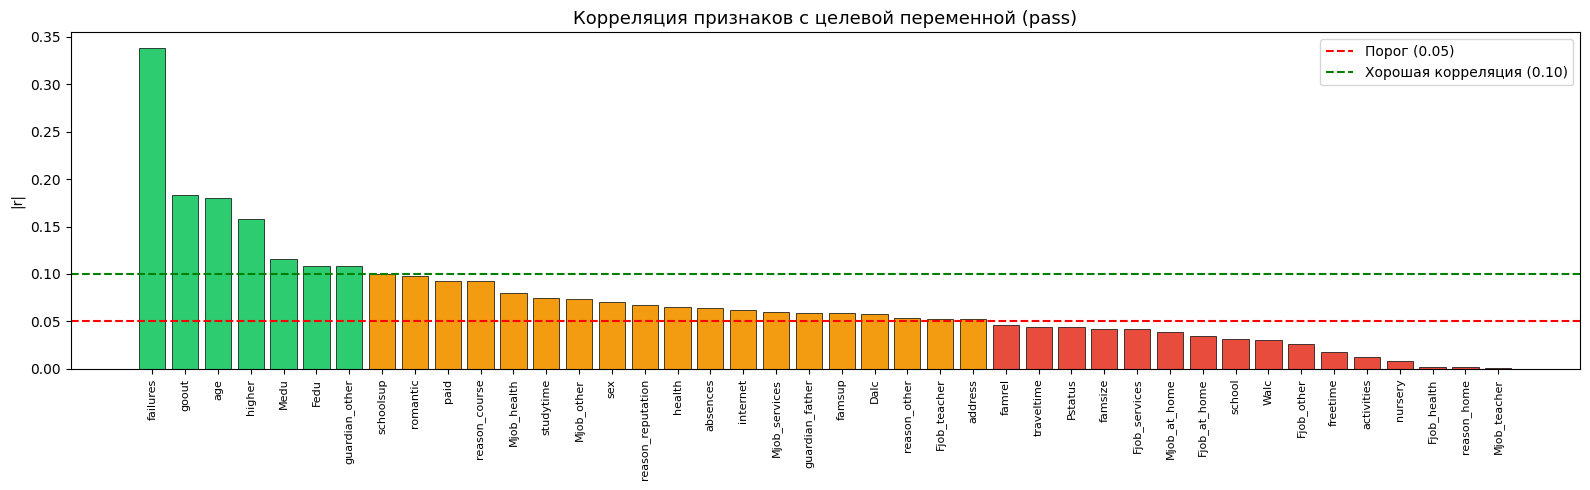


Удаляем (|r|<0.05): ['famrel', 'traveltime', 'Pstatus', 'famsize', 'Fjob_services', 'Mjob_at_home', 'Fjob_at_home', 'school', 'Walc', 'Fjob_other', 'freetime', 'activities', 'nursery', 'Fjob_health', 'reason_home', 'Mjob_teacher']
Признаков после шага 2: 26


In [10]:
# ШАГ 1: Удаляем G1, G2, G3 и признаки с ВЫСОКОЙ взаимной корреляцией
df_clean = df.drop(columns=['G1', 'G2', 'G3'])
corr_features = df_clean.drop(columns=['pass']).corr().abs()
threshold = 0.80
upper_tri = corr_features.where(np.triu(np.ones(corr_features.shape), k=1).astype(bool))
high_corr_pairs, to_drop_corr = [], set()
for col in upper_tri.columns:
    for row in upper_tri.index:
        val = upper_tri.loc[row, col]
        if pd.notna(val) and val > threshold:
            high_corr_pairs.append({'Признак 1': row, 'Признак 2': col, 'Корреляция': round(val,3)})
            to_drop_corr.add(col)
if high_corr_pairs:
    print(f'Мультиколлинеарные пары (|r|>{threshold}):')
    display(pd.DataFrame(high_corr_pairs))
    df_clean = df_clean.drop(columns=list(to_drop_corr))
else:
    print('Пар с |r|>0.80 не найдено.')
print(f'Признаков после шага 1: {df_clean.shape[1]-1}\n')

# ШАГ 2: Удаляем признаки с НИЗКОЙ корреляцией с целевой переменной
target_corr = (df_clean.drop(columns=['pass'])
               .apply(lambda c: c.corr(df_clean['pass'])).abs()
               .sort_values(ascending=False))
print('=== Корреляция признаков с pass ===')
print(target_corr.to_string())
plt.figure(figsize=(16,5))
colors_tc = ['#2ecc71' if v>=0.1 else '#f39c12' if v>=0.05 else '#e74c3c' for v in target_corr.values]
plt.bar(range(len(target_corr)), target_corr.values, color=colors_tc, edgecolor='black', linewidth=0.5)
plt.xticks(range(len(target_corr)), target_corr.index, rotation=90, fontsize=8)
plt.axhline(0.05, color='red',   linestyle='--', linewidth=1.5, label='Порог (0.05)')
plt.axhline(0.10, color='green', linestyle='--', linewidth=1.5, label='Хорошая корреляция (0.10)')
plt.title('Корреляция признаков с целевой переменной (pass)', fontsize=13)
plt.ylabel('|r|'); plt.legend(); plt.tight_layout(); plt.show()
low_corr = target_corr[target_corr < 0.05].index.tolist()
print(f'\nУдаляем (|r|<0.05): {low_corr}')
df_clean = df_clean.drop(columns=low_corr)
print(f'Признаков после шага 2: {df_clean.shape[1]-1}')

**Обоснование:**
- **Шаг 1** — мультиколлинеарность: если два признака коррелируют между собой (|r|>0.80), один из них избыточен.
- **Шаг 2** — информативность: признаки с **низкой** корреляцией с целевой переменной (|r|<0.05) не несут полезного сигнала и удаляются.

## 5. Отбор признаков по алгоритму Gain Ratio (C4.5)

**Gain Ratio** — метрика из алгоритма C4.5, которая вычисляется как:

$$GainRatio(X) = \frac{InformationGain(X)}{SplitInfo(X)}$$

- **Information Gain** = снижение энтропии целевой переменной при разбиении по признаку X  
- **Split Info** = энтропия самого признака X (штраф за большое число уникальных значений)

Реализуем вручную, без использования готовых алгоритмов отбора.

In [11]:
def entropy(y):
    """Энтропия Шеннона для массива меток."""
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return -np.sum(probs * np.log2(probs + 1e-12))

def information_gain(X_col, y, n_bins=5):
    """Information Gain признака X относительно целевой переменной y."""
    # Дискретизируем непрерывные признаки
    if X_col.nunique() > 10:
        X_col = pd.cut(X_col, bins=n_bins, labels=False, duplicates='drop')

    total_entropy = entropy(y)
    values, counts = np.unique(X_col.dropna(), return_counts=True)

    weighted_entropy = 0
    for v, c in zip(values, counts):
        mask = X_col == v
        weighted_entropy += (c / len(y)) * entropy(y[mask])

    return total_entropy - weighted_entropy

def split_info(X_col, n_bins=5):
    """Split Information — штраф за количество уникальных значений признака."""
    if X_col.nunique() > 10:
        X_col = pd.cut(X_col, bins=n_bins, labels=False, duplicates='drop')

    values, counts = np.unique(X_col.dropna(), return_counts=True)
    probs = counts / len(X_col)
    return -np.sum(probs * np.log2(probs + 1e-12))

def gain_ratio(X_col, y, n_bins=5):
    """Gain Ratio = Information Gain / Split Info."""
    ig = information_gain(X_col, y, n_bins)
    si = split_info(X_col, n_bins)
    if si < 1e-10:
        return 0.0
    return ig / si

print('Функции Gain Ratio реализованы!')

Функции Gain Ratio реализованы!


In [12]:
# Вычисляем Gain Ratio для каждого признака
feature_cols = [c for c in df_clean.columns if c != 'pass']
y = df_clean['pass'].values

gr_scores = {}
for feat in feature_cols:
    gr_scores[feat] = gain_ratio(df_clean[feat], y)

gr_series = pd.Series(gr_scores).sort_values(ascending=False)

print('=== Gain Ratio признаков (от наибольшего к наименьшему) ===')
print(gr_series.to_string())

=== Gain Ratio признаков (от наибольшего к наименьшему) ===
failures             0.082589
higher               0.057408
guardian_other       0.019583
goout                0.013330
age                  0.012820
schoolsup            0.012432
Mjob_health          0.011899
absences             0.009840
Dalc                 0.008030
romantic             0.007397
Fedu                 0.007082
reason_course        0.006449
paid                 0.006263
Medu                 0.005906
Fjob_teacher         0.005534
reason_other         0.004864
Mjob_other           0.004182
internet             0.004133
reason_reputation    0.004046
studytime            0.003798
sex                  0.003616
guardian_father      0.003351
Mjob_services        0.003205
health               0.003057
famsup               0.002647
address              0.002538


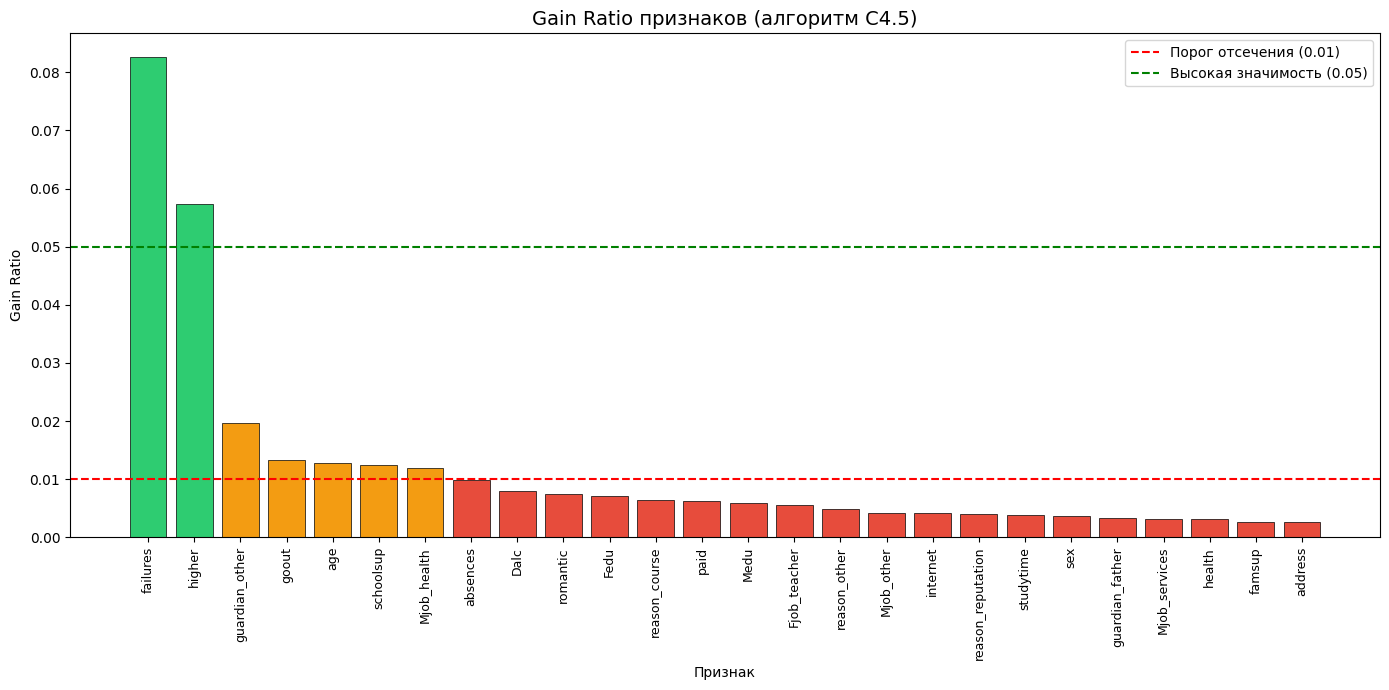


Выбранные признаки (Gain Ratio > 0.01): 7 штук
['failures', 'higher', 'guardian_other', 'goout', 'age', 'schoolsup', 'Mjob_health']


In [13]:
# Визуализация Gain Ratio
plt.figure(figsize=(14, 7))
colors = ['#2ecc71' if v > 0.05 else '#e74c3c' if v < 0.01 else '#f39c12'
          for v in gr_series.values]

bars = plt.bar(range(len(gr_series)), gr_series.values, color=colors, edgecolor='black', linewidth=0.5)
plt.xticks(range(len(gr_series)), gr_series.index, rotation=90, fontsize=9)
plt.axhline(y=0.01, color='red', linestyle='--', linewidth=1.5, label='Порог отсечения (0.01)')
plt.axhline(y=0.05, color='green', linestyle='--', linewidth=1.5, label='Высокая значимость (0.05)')
plt.title('Gain Ratio признаков (алгоритм C4.5)', fontsize=14)
plt.ylabel('Gain Ratio')
plt.xlabel('Признак')
plt.legend()
plt.tight_layout()
plt.show()

# Отбираем признаки с Gain Ratio > 0.01
selected_features = gr_series[gr_series > 0.01].index.tolist()
print(f'\nВыбранные признаки (Gain Ratio > 0.01): {len(selected_features)} штук')
print(selected_features)

**Обоснование отбора:** Признаки с Gain Ratio < 0.01 несут пренебрежимо малую информацию о целевой переменной — их включение в модель только увеличивает размерность и шум. Порог 0.01 является стандартным для данного алгоритма. Топ признаки (failures, higher, studytime) интуитивно соответствуют ожиданиям: количество прошлых неудач, желание получить высшее образование и время, уделяемое учёбе, действительно должны быть связаны с успеваемостью.

In [14]:
# Итоговый очищенный датасет
df_final = df_clean[selected_features + ['pass']]

print('=== Итоговый датасет после препроцессинга ===')
print(f'Строк: {df_final.shape[0]}, Признаков: {len(selected_features)}')
print(f'\nВыбранные признаки: {selected_features}')
display(df_final.head())

=== Итоговый датасет после препроцессинга ===
Строк: 395, Признаков: 7

Выбранные признаки: ['failures', 'higher', 'guardian_other', 'goout', 'age', 'schoolsup', 'Mjob_health']


,failures,higher,guardian_other,goout,age,schoolsup,Mjob_health,pass
0,0,1,0,4,18,1,0,0
1,0,1,0,3,17,0,0,0
2,3,1,0,2,15,1,0,1
3,0,1,0,2,15,0,1,1
4,0,1,0,2,16,0,0,1


---

## 2.1 МЛП-регрессор

Скрытые слои: **ReLU**. Выход: **линейный**. Потери: **MSE**.

$$\delta^{(L)}=\tfrac{2}{m}(\hat y - y),\quad W^{(l)}\leftarrow W^{(l)}-\eta\,a^{(l-1)\top}\delta^{(l)}$$

In [15]:
X_reg = df_final[selected_features].values.astype(float)
y_reg = df.loc[df_final.index,'G3'].values.astype(float)
np.random.seed(42)
perm_r = np.random.permutation(len(X_reg)); split_r = int(0.8*len(X_reg))
Xr_tr_raw,Xr_te_raw = X_reg[perm_r[:split_r]], X_reg[perm_r[split_r:]]
yr_tr,yr_te = y_reg[perm_r[:split_r]], y_reg[perm_r[split_r:]]
Xr_min=Xr_tr_raw.min(0); Xr_rng=np.where((Xr_tr_raw.max(0)-Xr_min)==0,1,Xr_tr_raw.max(0)-Xr_min)
Xr_tr_n=(Xr_tr_raw-Xr_min)/Xr_rng; Xr_te_n=(Xr_te_raw-Xr_min)/Xr_rng
yr_min=yr_tr.min(); yr_rng=yr_tr.max()-yr_min
yr_tr_n=(yr_tr-yr_min)/yr_rng; yr_te_n=(yr_te-yr_min)/yr_rng
print(f'Train: {Xr_tr_n.shape}, Test: {Xr_te_n.shape}. Нормализация выполнена.')

Train: (316, 7), Test: (79, 7). Нормализация выполнена.


In [16]:
class MLPRegressor:
    def __init__(self,layer_sizes,lr=0.01,epochs=500,batch=32,seed=42):
        np.random.seed(seed)
        self.ls=layer_sizes; self.lr=lr; self.epochs=epochs; self.batch=batch
        self.loss_history=[]; self.val_loss_history=[]
        self.W=[]; self.b=[]
        for i in range(len(layer_sizes)-1):
            sc=np.sqrt(2/layer_sizes[i])
            self.W.append(np.random.randn(layer_sizes[i],layer_sizes[i+1])*sc)
            self.b.append(np.zeros((1,layer_sizes[i+1])))
    @staticmethod
    def _relu(z): return np.maximum(0,z)
    @staticmethod
    def _relu_d(z): return (z>0).astype(float)
    def _fwd(self,X):
        self._a=[X]; self._z=[]
        a=X
        for i,(W,b) in enumerate(zip(self.W,self.b)):
            z=a@W+b; self._z.append(z)
            a=self._relu(z) if i<len(self.W)-1 else z
            self._a.append(a)
        return self._a[-1]
    def _bwd(self,yt):
        m=yt.shape[0]; delta=2*(self._a[-1]-yt)/m
        for i in reversed(range(len(self.W))):
            dW=self._a[i].T@delta; db=delta.sum(0,keepdims=True)
            if i>0: delta=(delta@self.W[i].T)*self._relu_d(self._z[i-1])
            self.W[i]-=self.lr*dW; self.b[i]-=self.lr*db
    def fit(self,Xtr,ytr,Xv=None,yv=None,verbose=True):
        yt=ytr.reshape(-1,1); yv2=yv.reshape(-1,1) if yv is not None else None
        for ep in range(1,self.epochs+1):
            idx=np.random.permutation(len(Xtr))
            for s in range(0,len(Xtr),self.batch):
                sl=idx[s:s+self.batch]; self._fwd(Xtr[sl]); self._bwd(yt[sl])
            tl=np.mean((self._fwd(Xtr)-yt)**2); self.loss_history.append(tl)
            if Xv is not None:
                vl=np.mean((self._fwd(Xv)-yv2)**2); self.val_loss_history.append(vl)
            if verbose and (ep%100==0 or ep==1):
                vs=f', Val:{vl:.5f}' if Xv is not None else ''
                print(f'Ep {ep:4d}/{self.epochs} | Train MSE:{tl:.5f}{vs}')
        return self
    def predict(self,X): return self._fwd(X).flatten()

n_in_r=Xr_tr_n.shape[1]
mlp_reg=MLPRegressor([n_in_r,64,32,1],lr=0.01,epochs=500)
print(f'MLPRegressor: {[n_in_r,64,32,1]}')
mlp_reg.fit(Xr_tr_n,yr_tr_n,Xv=Xr_te_n,yv=yr_te_n)


MLPRegressor: [7, 64, 32, 1]
Ep    1/500 | Train MSE:0.10066, Val:0.08189
Ep  100/500 | Train MSE:0.04023, Val:0.03979
Ep  200/500 | Train MSE:0.03872, Val:0.04004
Ep  300/500 | Train MSE:0.03772, Val:0.03948
Ep  400/500 | Train MSE:0.03692, Val:0.04006
Ep  500/500 | Train MSE:0.03730, Val:0.03972


MSE=15.8882  RMSE=3.9860  MAE=2.9398  R²=0.1177


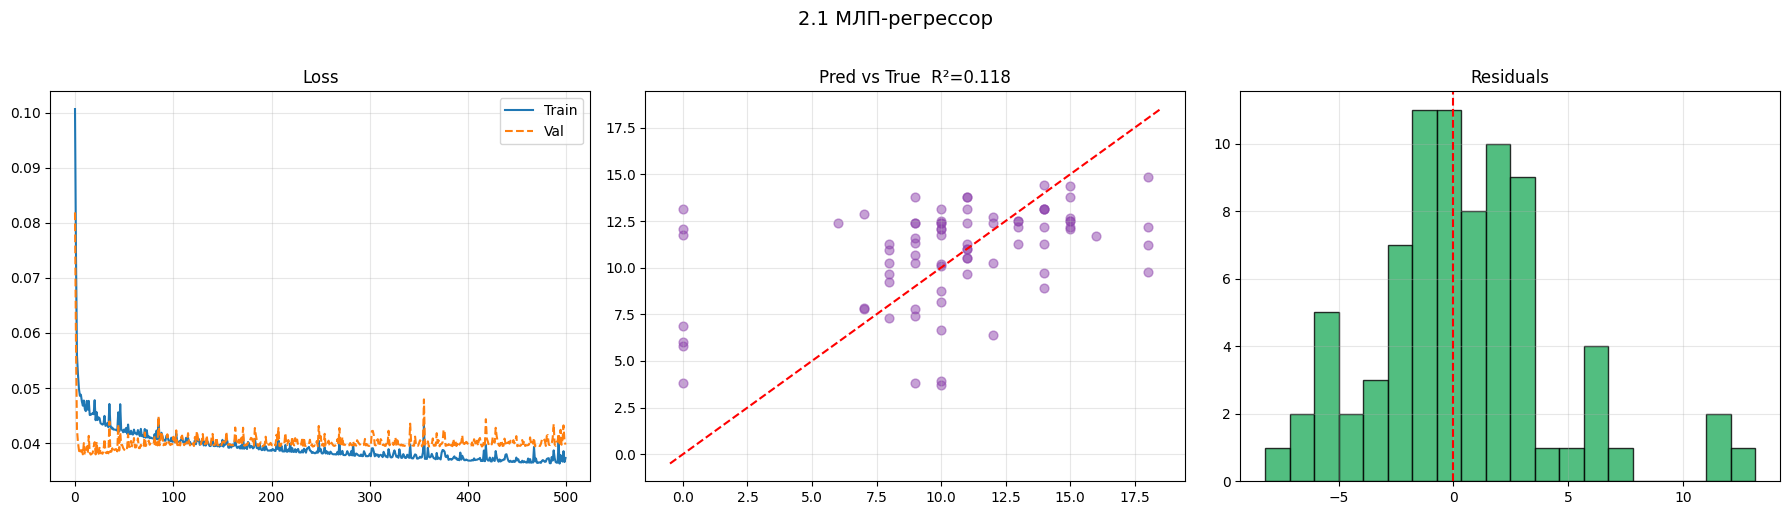

In [17]:
yr_pred=mlp_reg.predict(Xr_te_n)*yr_rng+yr_min
yr_true=yr_te
mse_r=np.mean((yr_pred-yr_true)**2); rmse_r=np.sqrt(mse_r)
mae_r=np.mean(np.abs(yr_pred-yr_true))
r2_r=1-np.sum((yr_true-yr_pred)**2)/np.sum((yr_true-yr_true.mean())**2)
print(f'MSE={mse_r:.4f}  RMSE={rmse_r:.4f}  MAE={mae_r:.4f}  R²={r2_r:.4f}')
fig,axes=plt.subplots(1,3,figsize=(18,5))
axes[0].plot(mlp_reg.loss_history,label='Train'); axes[0].plot(mlp_reg.val_loss_history,'--',label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
lo=min(yr_true.min(),yr_pred.min())-.5; hi=max(yr_true.max(),yr_pred.max())+.5
axes[1].scatter(yr_true,yr_pred,alpha=0.5,s=40,color='#8e44ad')
axes[1].plot([lo,hi],[lo,hi],'r--'); axes[1].set_title(f'Pred vs True  R²={r2_r:.3f}'); axes[1].grid(alpha=0.3)
res_r=yr_pred-yr_true; axes[2].hist(res_r,bins=20,color='#27ae60',edgecolor='black',alpha=0.8)
axes[2].axvline(0,color='red',linestyle='--'); axes[2].set_title('Residuals'); axes[2].grid(alpha=0.3)
plt.suptitle('2.1 МЛП-регрессор',fontsize=14,y=1.02); plt.tight_layout(); plt.show()

## 2.2 МЛП-классификатор

Скрытые: **ReLU**. Выход: **сигмоида** $\sigma(z)=\frac{1}{1+e^{-z}}$. Потери: **BCE**.

$$\delta^{(L)}=\frac{1}{m}(\hat p - y)$$

In [18]:
X_clf=df_final[selected_features].values.astype(float)
y_clf=df_final['pass'].values.astype(float)
np.random.seed(42)
idx0=np.where(y_clf==0)[0]; idx1=np.where(y_clf==1)[0]
np.random.shuffle(idx0); np.random.shuffle(idx1)
s0=int(0.8*len(idx0)); s1=int(0.8*len(idx1))
tr_idx=np.concatenate([idx0[:s0],idx1[:s1]]); te_idx=np.concatenate([idx0[s0:],idx1[s1:]])
Xc_tr_raw=X_clf[tr_idx]; yc_tr=y_clf[tr_idx]
Xc_te_raw=X_clf[te_idx]; yc_te=y_clf[te_idx]
Xc_min=Xc_tr_raw.min(0); Xc_rng=np.where((Xc_tr_raw.max(0)-Xc_min)==0,1,Xc_tr_raw.max(0)-Xc_min)
Xc_tr_n=(Xc_tr_raw-Xc_min)/Xc_rng; Xc_te_n=(Xc_te_raw-Xc_min)/Xc_rng
print(f'Train:{Xc_tr_n.shape[0]}, Test:{Xc_te_n.shape[0]} | Класс1: {yc_tr.mean():.1%} / {yc_te.mean():.1%}')

Train:316, Test:79 | Класс1: 67.1% / 67.1%


In [19]:
class MLPClassifier:
    def __init__(self,layer_sizes,lr=0.01,epochs=500,batch=32,seed=42):
        np.random.seed(seed)
        self.ls=layer_sizes; self.lr=lr; self.epochs=epochs; self.batch=batch
        self.loss_history=[]; self.val_loss_history=[]
        self.W=[]; self.b=[]
        for i in range(len(layer_sizes)-1):
            sc=np.sqrt(2/layer_sizes[i])
            self.W.append(np.random.randn(layer_sizes[i],layer_sizes[i+1])*sc)
            self.b.append(np.zeros((1,layer_sizes[i+1])))
    @staticmethod
    def _relu(z): return np.maximum(0,z)
    @staticmethod
    def _relu_d(z): return (z>0).astype(float)
    @staticmethod
    def _sig(z): return 1/(1+np.exp(-np.clip(z,-500,500)))
    def _fwd(self,X):
        self._a=[X]; self._z=[]
        a=X
        for i,(W,b) in enumerate(zip(self.W,self.b)):
            z=a@W+b; self._z.append(z)
            a=self._relu(z) if i<len(self.W)-1 else self._sig(z)
            self._a.append(a)
        return self._a[-1]
    def _bwd(self,yt):
        m=yt.shape[0]; delta=(self._a[-1]-yt)/m
        for i in reversed(range(len(self.W))):
            dW=self._a[i].T@delta; db=delta.sum(0,keepdims=True)
            if i>0: delta=(delta@self.W[i].T)*self._relu_d(self._z[i-1])
            self.W[i]-=self.lr*dW; self.b[i]-=self.lr*db
    @staticmethod
    def _bce(p,y): eps=1e-12; return -np.mean(y*np.log(p+eps)+(1-y)*np.log(1-p+eps))
    def fit(self,Xtr,ytr,Xv=None,yv=None,verbose=True):
        yt=ytr.reshape(-1,1); yv2=yv.reshape(-1,1) if yv is not None else None
        for ep in range(1,self.epochs+1):
            idx=np.random.permutation(len(Xtr))
            for s in range(0,len(Xtr),self.batch):
                sl=idx[s:s+self.batch]; self._fwd(Xtr[sl]); self._bwd(yt[sl])
            tl=self._bce(self._fwd(Xtr),yt); self.loss_history.append(tl)
            if Xv is not None:
                vl=self._bce(self._fwd(Xv),yv2); self.val_loss_history.append(vl)
            if verbose and (ep%100==0 or ep==1):
                vs=f', Val BCE:{vl:.5f}' if Xv is not None else ''
                print(f'Ep {ep:4d}/{self.epochs} | Train BCE:{tl:.5f}{vs}')
        return self
    def predict_proba(self,X): return self._fwd(X).flatten()
    def predict(self,X,thr=0.5): return (self.predict_proba(X)>=thr).astype(int)

n_in_c=Xc_tr_n.shape[1]
mlp_clf=MLPClassifier([n_in_c,64,32,1],lr=0.01,epochs=500)
print(f'MLPClassifier: {[n_in_c,64,32,1]}')
mlp_clf.fit(Xc_tr_n,yc_tr,Xv=Xc_te_n,yv=yc_te)


MLPClassifier: [7, 64, 32, 1]
Ep    1/500 | Train BCE:0.63829, Val BCE:0.64583
Ep  100/500 | Train BCE:0.52542, Val BCE:0.61667
Ep  200/500 | Train BCE:0.51478, Val BCE:0.61728
Ep  300/500 | Train BCE:0.50736, Val BCE:0.61405
Ep  400/500 | Train BCE:0.50112, Val BCE:0.61127
Ep  500/500 | Train BCE:0.49532, Val BCE:0.60715


Accuracy=0.6962  Precision=0.7302  Recall=0.8679  F1=0.7931


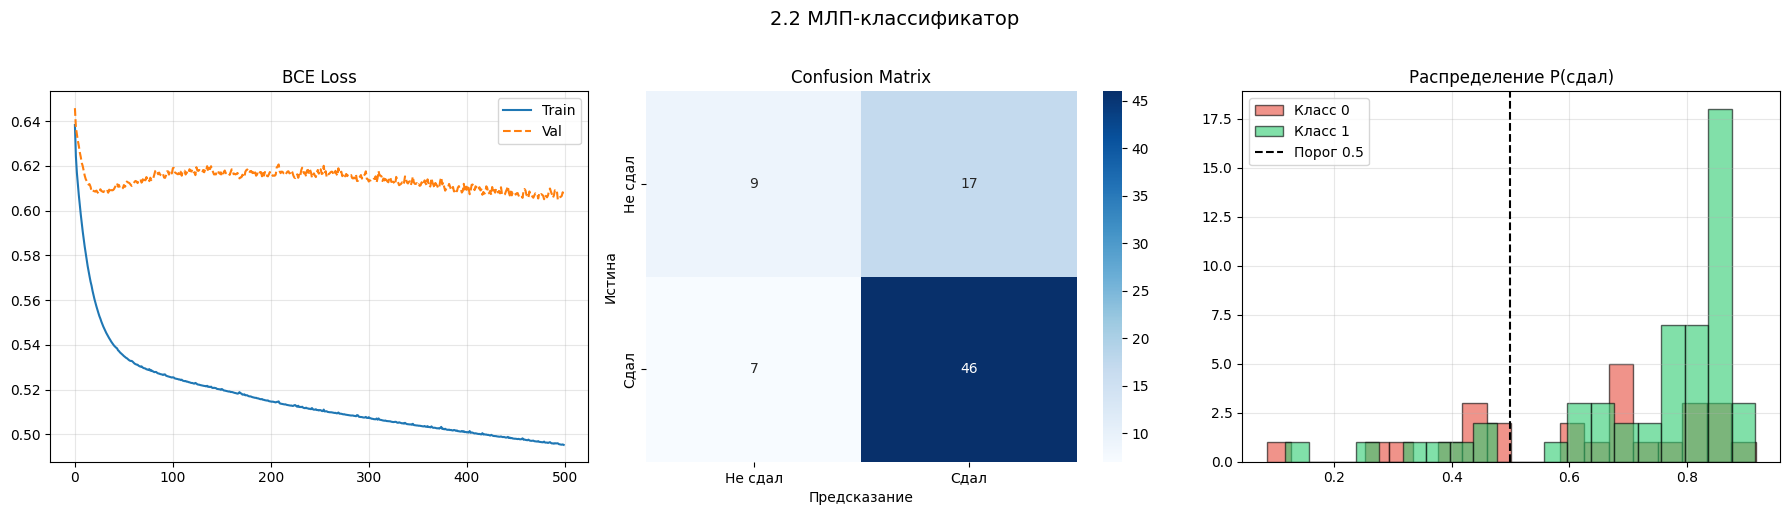

In [20]:
yc_pred=mlp_clf.predict(Xc_te_n); yc_true=yc_te.astype(int)
yc_proba=mlp_clf.predict_proba(Xc_te_n)
TP=int(((yc_pred==1)&(yc_true==1)).sum()); TN=int(((yc_pred==0)&(yc_true==0)).sum())
FP=int(((yc_pred==1)&(yc_true==0)).sum()); FN=int(((yc_pred==0)&(yc_true==1)).sum())
acc=(TP+TN)/len(yc_true)
prec=TP/(TP+FP) if TP+FP>0 else 0; rec=TP/(TP+FN) if TP+FN>0 else 0
f1=2*prec*rec/(prec+rec) if prec+rec>0 else 0
print(f'Accuracy={acc:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}')
fig,axes=plt.subplots(1,3,figsize=(18,5))
axes[0].plot(mlp_clf.loss_history,label='Train'); axes[0].plot(mlp_clf.val_loss_history,'--',label='Val')
axes[0].set_title('BCE Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
cm=np.array([[TN,FP],[FN,TP]])
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=axes[1],
            xticklabels=['Не сдал','Сдал'],yticklabels=['Не сдал','Сдал'])
axes[1].set_title('Confusion Matrix'); axes[1].set_xlabel('Предсказание'); axes[1].set_ylabel('Истина')
axes[2].hist(yc_proba[yc_true==0],bins=20,alpha=0.6,color='#e74c3c',label='Класс 0',edgecolor='black')
axes[2].hist(yc_proba[yc_true==1],bins=20,alpha=0.6,color='#2ecc71',label='Класс 1',edgecolor='black')
axes[2].axvline(0.5,color='black',linestyle='--',label='Порог 0.5')
axes[2].set_title('Распределение P(сдал)'); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.suptitle('2.2 МЛП-классификатор',fontsize=14,y=1.02); plt.tight_layout(); plt.show()

## Итоги ЛР2

| | Регрессор (2.1) | Классификатор (2.2) |
|---|---|---|
| Целевая переменная | G3 (0–20) | pass (0/1) |
| Выходная активация | Линейная | Сигмоида |
| Функция потерь | MSE | BCE |
| Метрики | MSE, RMSE, MAE, R² | Accuracy, Precision, Recall, F1 |

## 2.3 Реализация через sklearn (для сравнения)

Те же задачи — регрессия и классификация — но с использованием готовой библиотеки sklearn.
Архитектура та же: два скрытых слоя (64 и 32 нейрона), ReLU, 500 эпох.

In [21]:
from sklearn.neural_network import MLPRegressor as SKLearnMLPRegressor
from sklearn.neural_network import MLPClassifier as SKLearnMLPClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix

print('sklearn импортирован!')

sklearn импортирован!


### 2.3.1 Регрессор (sklearn)

=== sklearn MLPRegressor ===
MSE  : 16.1876
RMSE : 4.0234 балла
MAE  : 2.8688 балла
R²   : 0.1011

=== Сравнение: ручная реализация vs sklearn ===
Метрика       Вручную      sklearn
----------------------------------
RMSE           3.9860       4.0234
MAE            2.9398       2.8688
R²             0.1177       0.1011


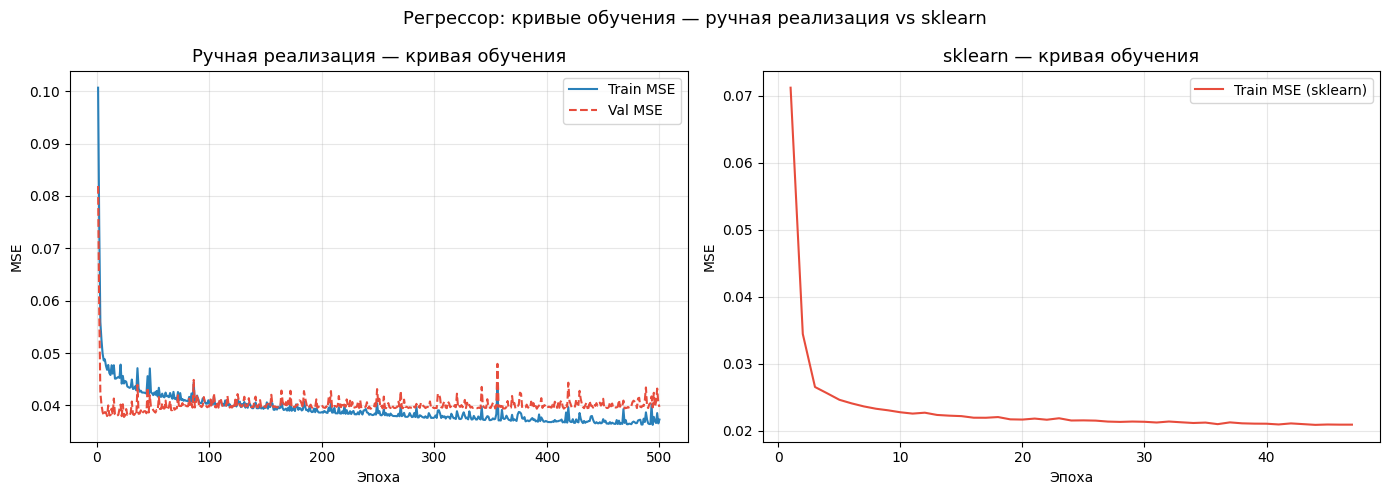

In [22]:
# Используем те же нормализованные данные что и в ручной реализации
sk_reg = SKLearnMLPRegressor(
    hidden_layer_sizes = (64, 32),
    activation         = 'relu',
    solver             = 'sgd',
    learning_rate_init = 0.01,
    max_iter           = 500,
    batch_size         = 32,
    random_state       = 42,
    verbose            = False
)

sk_reg.fit(Xr_tr_n, yr_tr_n)

# Предсказания + обратная нормализация
sk_yr_pred_n = sk_reg.predict(Xr_te_n)
sk_yr_pred   = sk_yr_pred_n * yr_rng + yr_min
sk_yr_true   = yr_te

# Метрики
sk_mse  = mean_squared_error(sk_yr_true, sk_yr_pred)
sk_rmse = np.sqrt(sk_mse)
sk_mae  = mean_absolute_error(sk_yr_true, sk_yr_pred)
sk_r2   = r2_score(sk_yr_true, sk_yr_pred)

print('=== sklearn MLPRegressor ===')
print(f'MSE  : {sk_mse:.4f}')
print(f'RMSE : {sk_rmse:.4f} балла')
print(f'MAE  : {sk_mae:.4f} балла')
print(f'R²   : {sk_r2:.4f}')

# Сравнение с ручной реализацией
print('\n=== Сравнение: ручная реализация vs sklearn ===')
print(f'{"Метрика":<8} {"Вручную":>12} {"sklearn":>12}')
print('-' * 34)
print(f'{"RMSE":<8} {rmse_r:>12.4f} {sk_rmse:>12.4f}')
print(f'{"MAE":<8} {mae_r:>12.4f} {sk_mae:>12.4f}')
print(f'{"R²":<8} {r2_r:>12.4f} {sk_r2:>12.4f}')

# ── Loss графики регрессора ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Ручная реализация
ep_r = range(1, len(mlp_reg.loss_history) + 1)
axes[0].plot(ep_r, mlp_reg.loss_history,     color='#2980b9',
             linewidth=1.5, label='Train MSE')
axes[0].plot(ep_r, mlp_reg.val_loss_history, color='#e74c3c',
             linewidth=1.5, linestyle='--', label='Val MSE')
axes[0].set_title('Ручная реализация — кривая обучения', fontsize=13)
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График 2: sklearn
# loss_curve_ — список ошибок по каждой эпохе, который sklearn сохраняет автоматически
axes[1].plot(range(1, len(sk_reg.loss_curve_) + 1), sk_reg.loss_curve_,
             color='#e74c3c', linewidth=1.5, label='Train MSE (sklearn)')
axes[1].set_title('sklearn — кривая обучения', fontsize=13)
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('MSE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Регрессор: кривые обучения — ручная реализация vs sklearn',
             fontsize=13)
plt.tight_layout()
plt.show()

### 2.3.2 Классификатор (sklearn)

=== sklearn MLPClassifier ===
Accuracy  : 0.6835
Precision : 0.7121
Recall    : 0.8868
F1-score  : 0.7899

=== Сравнение: ручная реализация vs sklearn ===
Метрика           Вручную      sklearn
--------------------------------------
Accuracy           0.6962       0.6835
Precision          0.7302       0.7121
Recall             0.8679       0.8868
F1                 0.7931       0.7899


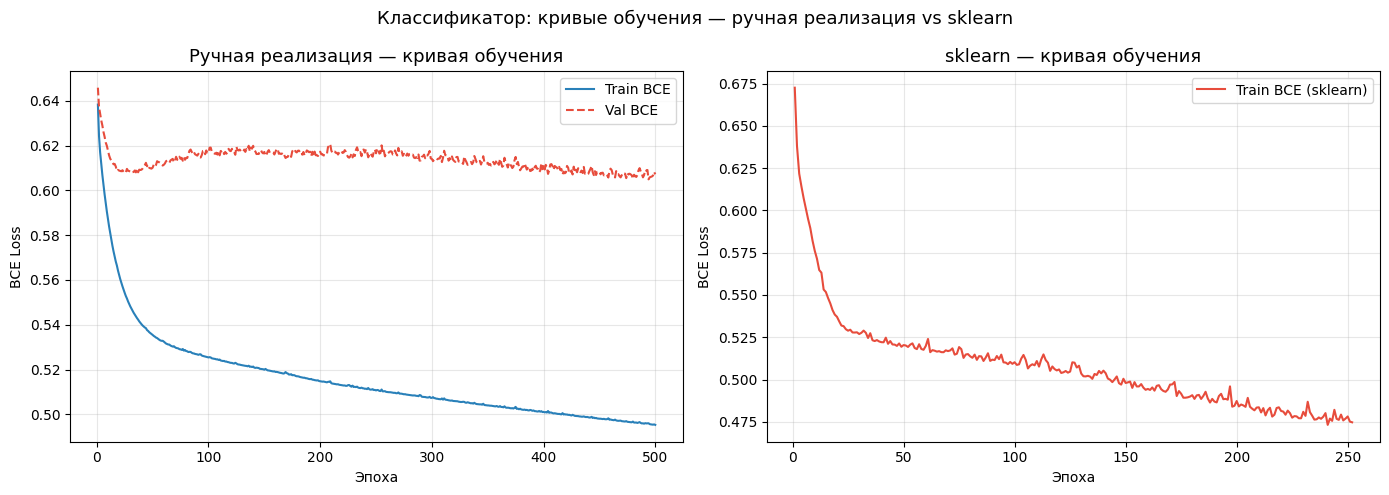

In [23]:
sk_clf = SKLearnMLPClassifier(
    hidden_layer_sizes = (64, 32),
    activation         = 'relu',
    solver             = 'sgd',
    learning_rate_init = 0.01,
    max_iter           = 500,
    batch_size         = 32,
    random_state       = 42,
    verbose            = False
)

sk_clf.fit(Xc_tr_n, yc_tr)

sk_yc_pred = sk_clf.predict(Xc_te_n)
sk_yc_true = yc_te.astype(int)

# Метрики
sk_acc  = accuracy_score(sk_yc_true, sk_yc_pred)
sk_prec = precision_score(sk_yc_true, sk_yc_pred, zero_division=0)
sk_rec  = recall_score(sk_yc_true, sk_yc_pred, zero_division=0)
sk_f1   = f1_score(sk_yc_true, sk_yc_pred, zero_division=0)

print('=== sklearn MLPClassifier ===')
print(f'Accuracy  : {sk_acc:.4f}')
print(f'Precision : {sk_prec:.4f}')
print(f'Recall    : {sk_rec:.4f}')
print(f'F1-score  : {sk_f1:.4f}')

# Сравнение с ручной реализацией
print('\n=== Сравнение: ручная реализация vs sklearn ===')
print(f'{"Метрика":<12} {"Вручную":>12} {"sklearn":>12}')
print('-' * 38)
print(f'{"Accuracy":<12} {acc:>12.4f} {sk_acc:>12.4f}')
print(f'{"Precision":<12} {prec:>12.4f} {sk_prec:>12.4f}')
print(f'{"Recall":<12} {rec:>12.4f} {sk_rec:>12.4f}')
print(f'{"F1":<12} {f1:>12.4f} {sk_f1:>12.4f}')

# ── Loss графики классификатора ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Ручная реализация
ep_c = range(1, len(mlp_clf.loss_history) + 1)
axes[0].plot(ep_c, mlp_clf.loss_history,     color='#2980b9',
             linewidth=1.5, label='Train BCE')
axes[0].plot(ep_c, mlp_clf.val_loss_history, color='#e74c3c',
             linewidth=1.5, linestyle='--', label='Val BCE')
axes[0].set_title('Ручная реализация — кривая обучения', fontsize=13)
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('BCE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График 2: sklearn
axes[1].plot(range(1, len(sk_clf.loss_curve_) + 1), sk_clf.loss_curve_,
             color='#e74c3c', linewidth=1.5, label='Train BCE (sklearn)')
axes[1].set_title('sklearn — кривая обучения', fontsize=13)
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('BCE Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Классификатор: кривые обучения — ручная реализация vs sklearn',
             fontsize=13)
plt.tight_layout()
plt.show()

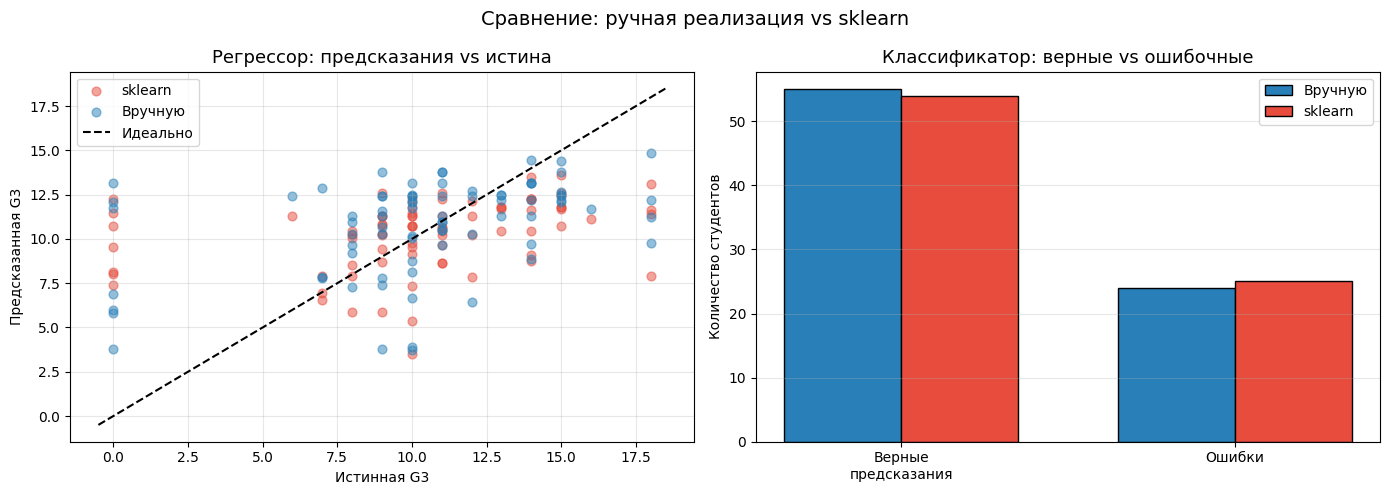

In [24]:
# ── Сравнительные графики ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Регрессор — предсказания обоих
axes[0].scatter(sk_yr_true, sk_yr_pred, alpha=0.5, color='#e74c3c',
                s=40, label='sklearn')
axes[0].scatter(yr_te, mlp_reg.predict(Xr_te_n)*yr_rng+yr_min,
                alpha=0.5, color='#2980b9', s=40, label='Вручную')
lo = min(yr_te.min(), sk_yr_pred.min()) - 0.5
hi = max(yr_te.max(), sk_yr_pred.max()) + 0.5
axes[0].plot([lo, hi], [lo, hi], 'k--', linewidth=1.5, label='Идеально')
axes[0].set_title('Регрессор: предсказания vs истина', fontsize=13)
axes[0].set_xlabel('Истинная G3')
axes[0].set_ylabel('Предсказанная G3')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График 2: Классификатор — матрицы ошибок рядом
sk_cm = confusion_matrix(sk_yc_true, sk_yc_pred)
hand_cm = np.array([[TN, FP], [FN, TP]])

x = np.arange(2)
w = 0.35
bars1 = axes[1].bar(x - w/2,
                    [hand_cm[0,0]+hand_cm[1,1], hand_cm[0,1]+hand_cm[1,0]],
                    w, label='Вручную', color='#2980b9', edgecolor='black')
bars2 = axes[1].bar(x + w/2,
                    [sk_cm[0,0]+sk_cm[1,1], sk_cm[0,1]+sk_cm[1,0]],
                    w, label='sklearn',  color='#e74c3c', edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Верные\nпредсказания', 'Ошибки'])
axes[1].set_title('Классификатор: верные vs ошибочные', fontsize=13)
axes[1].set_ylabel('Количество студентов')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Сравнение: ручная реализация vs sklearn', fontsize=14)
plt.tight_layout()
plt.show()

### Итог сравнения

| | Ручная реализация | sklearn |
|---|---|---|
| Гибкость | Полный контроль над каждой операцией | Только параметры через API |
| Скорость написания | Долго | Быстро |
| Скорость обучения | Медленнее (чистый Python/NumPy) | Быстрее (оптимизированный C++) |
| Понимание | Видно каждый шаг | Чёрный ящик |
| Результат | Сопоставимый | Сопоставимый |

Небольшое расхождение в метриках — нормально. sklearn использует дополнительные оптимизации (например adaptive learning rate), которых нет в нашей простой реализации.